In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

In [2]:
train_data = datasets.FashionMNIST(root="data",
                      train=True,
                      download=True,
                      transform=ToTensor(),
                      target_transform=None)

test_data = datasets.FashionMNIST(root="data",
                      train=False,
                      download=True,
                      transform=ToTensor(),
                      target_transform=None)

In [3]:
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [4]:
len(train_data.classes)

10

In [5]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [6]:
train_data.target_transform

In [7]:
img1, label1 = train_data[0]
label1

9

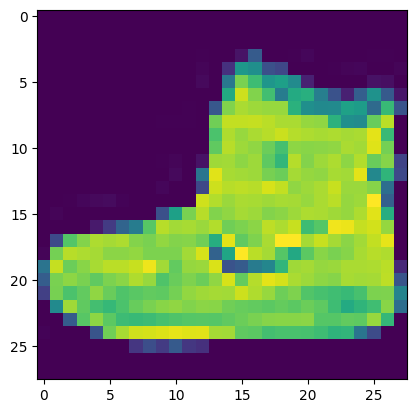

In [8]:
plt.imshow(img1.squeeze())

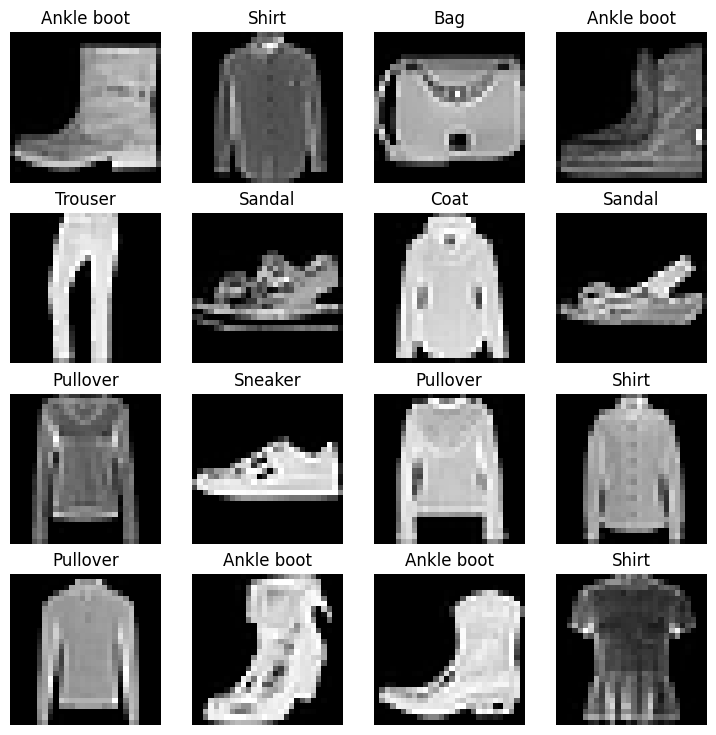

In [9]:
class_names = train_data.classes

# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);


In [10]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
for x, y in test_dataloader:
    print(x.shape)
    break

print(len(test_dataloader))

torch.Size([32, 1, 28, 28])
313


In [11]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))

train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

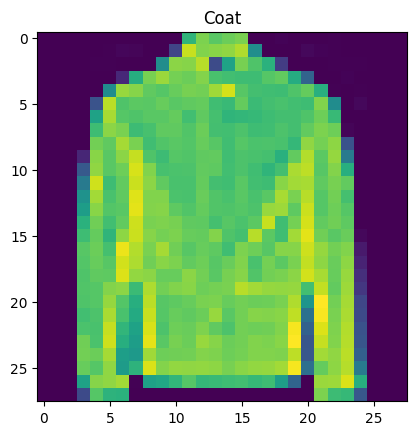

In [12]:
idx = 1

img, label = train_features_batch[idx], train_labels_batch[idx]

plt.title(f"{class_names[label]}")
plt.imshow(img.squeeze())

In [44]:
import torch.nn.functional as F
import pandas as pd


class FashionMNISTClassificator(nn.Module):
    def __init__(self):
        super().__init__()
        # self.layer = nn.Sequential(
        #     nn.Conv2d(1,10,kernel_size=3,padding=1),
        #     nn.ReLU(),
        #     nn.Conv2d(10,10,kernel_size=3,padding=1),
        #     nn.ReLU(),
        #     nn.MaxPool2d(kernel_size=2,stride=2),
        #     nn.Conv2d(10,10, kernel_size=3,padding=1),
        #     nn.ReLU(),
        #     nn.Conv2d(10,10, kernel_size=3,padding=1),
        #     nn.ReLU(),
        #     nn.Conv2d(10,10, kernel_size=3,padding=1),
        #     nn.ReLU(),
        #     nn.MaxPool2d(kernel_size=2,stride=2),
        #     nn.Flatten(),
        #     nn.Linear(490,64),
        #     nn.ReLU(),
        #     nn.Linear(64,64),
        #     nn.ReLU(),
        #     nn.Linear(64,10),
        #     nn.Softmax()
        # )
        self.block1 = nn.Sequential(
            nn.Conv2d(1,10,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(10,10, kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.FCL = nn.Sequential(
            nn.Flatten(),
            nn.Linear(10*7*7,16),
            nn.ReLU(),
            nn.Linear(16,16),
            nn.ReLU(),
            nn.Linear(16,10),
        )
    
    def forward(self,x:torch.tensor) -> torch.tensor:
        x = self.block1(x)
        # print(x.shape)
        x = self.block2(x)
        # print(x.shape)
        x = self.FCL(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model = FashionMNISTClassificator()

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


total_params = sum(param.numel() for param in model.parameters())
print(total_params)

# table = pd.DataFrame({"Module": [], "Parameters": []})
# for name, parameter in model.named_parameters():
#     if not parameter.requires_grad:
#         continue
#     params = parameter.numel()
#     table.loc[len(table)] = [name, params]
# table

9308


In [45]:

model(img1.unsqueeze(0))

tensor([[-0.1768,  0.0634,  0.1278, -0.2350,  0.1163,  0.0744,  0.1067,  0.1034,
         -0.0417,  0.0573]], grad_fn=<AddmmBackward0>)

In [ ]:
from tqdm.auto import tqdm
from functions import accuracy_fn

epochs = 5


def train_step(model: nn.Module,
               data_loader: DataLoader,
               loss_function: nn.Module,
               optimizer: torch.optim.Optimizer,
               device):
    
    model.to(device=device)

    loss_train_total = 0
    acc_train = 0

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        model.train()

        pred_train = model(X)
        # break

        loss_train = loss_function(pred_train, y)
        loss_train_total += loss_train

        optimizer.zero_grad()

        loss_train.backward()
        optimizer.step()

        pred_train_class = F.softmax(pred_train, dim=1).argmax(axis=1)

        acc_train += accuracy_fn(y, pred_train_class)

    loss_train /= len(data_loader)
    acc_train /= len(data_loader)

    print(f"Loss: {loss_train:.5f}, Accuracy: {acc_train:.2f}%")

def test_step(model: nn.Module,
              data_loader: DataLoader,
              loss_function: nn.Module,
              device):
    model.to(device=device)
    
    loss_test, acc_test = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y  in data_loader:
            X, y = X.to(device), y.to(device)

            pred_test = model(X)
            pred_test_class = F.softmax(pred_test, dim=1).argmax(axis=1)

            loss_test += loss_function(pred_test, y)
            acc_test += accuracy_fn(y, pred_test_class)

        loss_test /= len(data_loader)
        acc_test /= len(data_loader)
    print(f"Test loss: {loss_test:.5f}, Test acc: {acc_test:.2f}%")

for epoch in range(epochs):
    # print(f"Epoch: {epoch}\n---------")
    train_step(model,train_dataloader,loss_function,optimizer,"cpu")
    test_step(model,test_dataloader,loss_function,"cpu")

Loss: 0.00022, Accuracy: 87.57%
Test loss: 0.41939, Test acc: 84.30%
Loss: 0.00017, Accuracy: 87.70%
Test loss: 0.36223, Test acc: 87.16%
Loss: 0.00022, Accuracy: 87.68%
Test loss: 0.36690, Test acc: 86.96%
Loss: 0.00028, Accuracy: 87.98%
Test loss: 0.36770, Test acc: 86.93%
Loss: 0.00016, Accuracy: 87.99%
Test loss: 0.40310, Test acc: 85.23%


In [47]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               device):
    """Evaluates a given model on a given dataset.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.
        device (str, optional): Target device to compute on. Defaults to device.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to the target device
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=F.softmax(y_pred,dim=1).argmax(dim=1))
        
        # Scale loss and acc
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 1 results with device-agnostic code 
model_results = eval_model(model=model,
                        data_loader=test_dataloader,
                        loss_fn=loss_function,
                        device="cpu"
)
model_results

{'model_name': 'FashionMNISTClassificator',
 'model_loss': 0.3950127363204956,
 'model_acc': 87.39017571884985}

In [48]:


def make_predictions(model: torch.nn.Module, data: list, device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())
            
    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)


import random
# random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 8 (Bag)


In [49]:
pred_probs= make_predictions(model=model, 
                             data=test_samples,
                             device="cpu")

pred_classes = pred_probs.argmax(dim=1)
pred_classes

# View first two prediction probabilities list
pred_probs[:2]

tensor([[3.1282e-06, 1.5156e-07, 4.5617e-07, 8.0657e-06, 3.9413e-06, 2.4525e-08,
         8.2360e-07, 6.3429e-06, 9.9998e-01, 9.4470e-07],
        [1.7007e-08, 4.3970e-11, 1.2369e-09, 6.9171e-09, 3.4713e-08, 2.3145e-11,
         9.6536e-09, 1.9589e-09, 1.0000e+00, 5.3460e-10]])

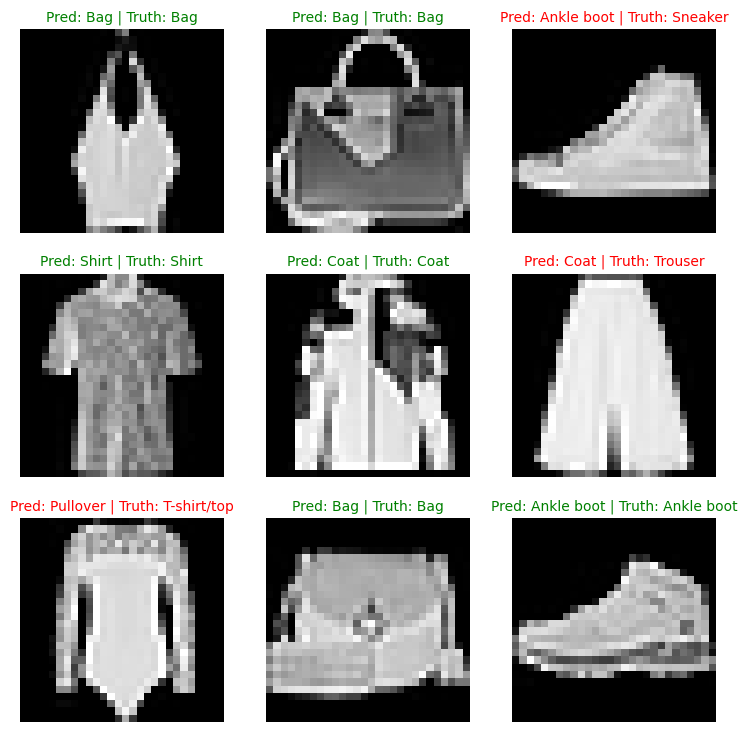

In [50]:


# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]] 

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  
  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);


In [76]:
# 1. Make predictions with trained model
device = "cpu"
y_preds = []
model.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model(X)
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions: 100%|██████████| 313/313 [00:00<00:00, 919.34it/s]


In [77]:
from torchmetrics import ConfusionMatrix
import mlxtend

mlxtend.__version__

'0.23.4'

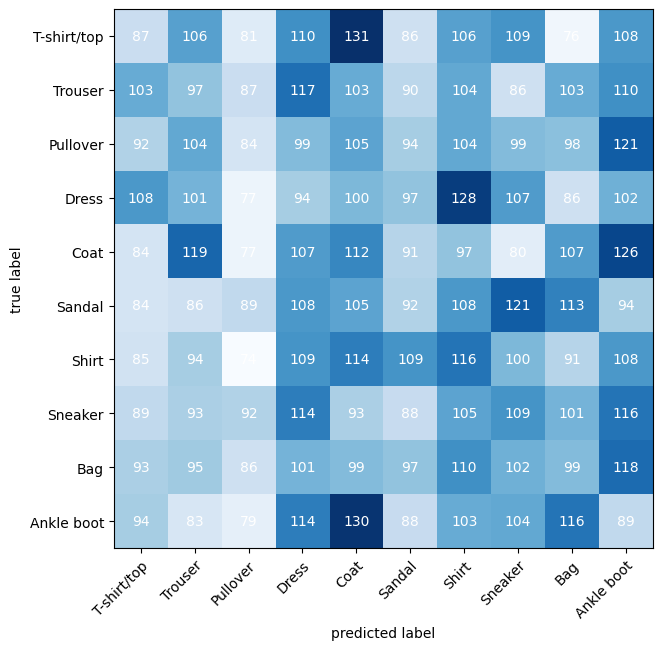

In [78]:
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib likes working with NumPy 
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10, 7)
);

In [63]:
from pathlib import Path

MODELS_PATH = Path("models")
MODELS_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "CNN_model.pth"
MODEL_SAVE_PATH = MODELS_PATH / MODEL_NAME

torch.save(model.state_dict(), MODEL_SAVE_PATH)


In [66]:
model_loaded = FashionMNISTClassificator()
model_loaded.load_state_dict(torch.load(MODEL_SAVE_PATH))
model_loaded

FashionMNISTClassificator(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (FCL): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=16, bias=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=10, bias=True)
  )
)

In [67]:
eval_model(model_loaded, test_dataloader, loss_function, "cpu")

{'model_name': 'FashionMNISTClassificator',
 'model_loss': 0.40295305848121643,
 'model_acc': 85.24361022364218}

In [ ]:
# Create a convolutional neural network 
class FashionMNISTModelV2(nn.Module):
    """
    Model architecture copying TinyVGG from: 
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number 
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from? 
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7, 
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, 
    hidden_units=10, 
    output_shape=len(class_names)).to(device)

loss_function_2 = nn.CrossEntropyLoss()
optimizer_2 = torch.optim.Adam(model_2.parameters(),lr=0.01)


In [71]:
for epoch in range(epochs):
    train_step(model_2, train_dataloader, loss_function_2, optimizer_2, "cpu")
    test_step(model_2, test_dataloader, loss_function_2, "cpu")

Loss: 0.00013, Accuracy: 87.00%
Test loss: 0.39757, Test acc: 85.15%
Loss: 0.00017, Accuracy: 87.36%
Test loss: 0.37121, Test acc: 86.34%
Loss: 0.00023, Accuracy: 87.50%
Test loss: 0.37605, Test acc: 86.69%
Loss: 0.00020, Accuracy: 87.39%
Test loss: 0.35416, Test acc: 87.07%
Loss: 0.00014, Accuracy: 87.63%
Test loss: 0.38061, Test acc: 87.08%


In [74]:
device = "cpu"
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model_2(X)
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

Making predictions: 100%|██████████| 313/313 [00:00<00:00, 627.91it/s]


tensor([8, 3, 4,  ..., 8, 9, 8])

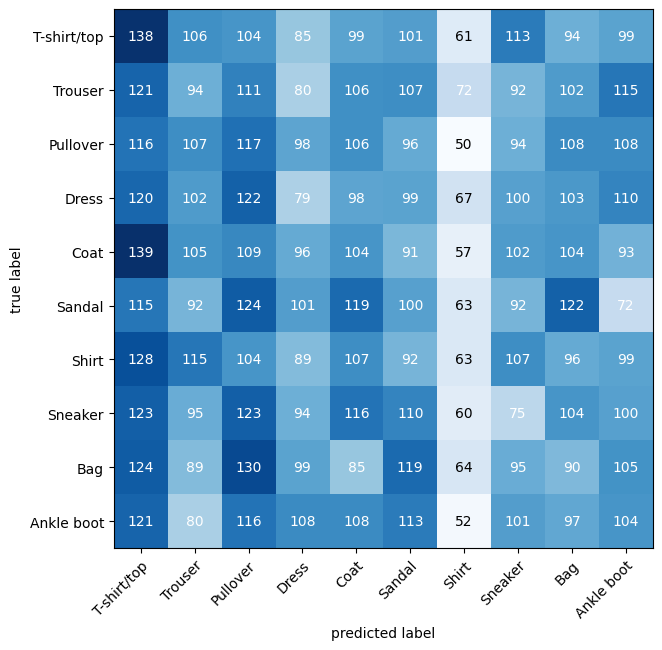

In [75]:
# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib likes working with NumPy 
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10, 7)
);